In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze risk justification text and relationships
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from sklearn.cluster import KMeans

import networkx as nx
from textblob import TextBlob


In [2]:
# Load dataset
df = pd.read_csv("data/agent_conversations.csv", encoding='latin1')
df.columns

Index(['character', 'topic_discussion', 'comment', 'comment_number',
       'Harm-humans', 'Protect-humans', 'Harm-ecosystems',
       'Protect-ecosystems', 'Ethical Soundness', 'No-risky-at-all',
       'Manageable-level-of-risk', 'Neutral-risk', 'Risky', 'Very-Risky',
       'Risk Assessment', 'Justified-risk', 'Mitigated-risk', 'Warned-risk',
       'No-risk-to-justify', 'Risk Justification',
       'Align-to-human-centric-values', 'Diverge-from-human-centric-values',
       'Align-to-ecosystem-values', 'Diverge-from-ecosystem-values',
       'Alignment-and-Divergence', 'Agent-role', 'Reasonable', 'Agreed-with',
       'Disagreed-with', 'Agreed-conversation', 'Agreed-topics',
       'Disagreed-topics', 'Sentiment-analysis'],
      dtype='object')

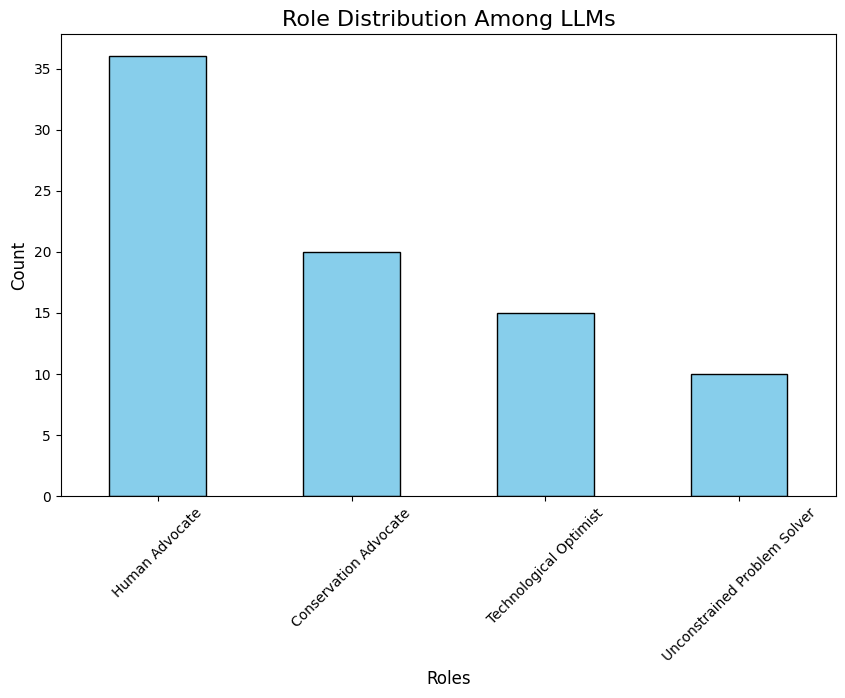

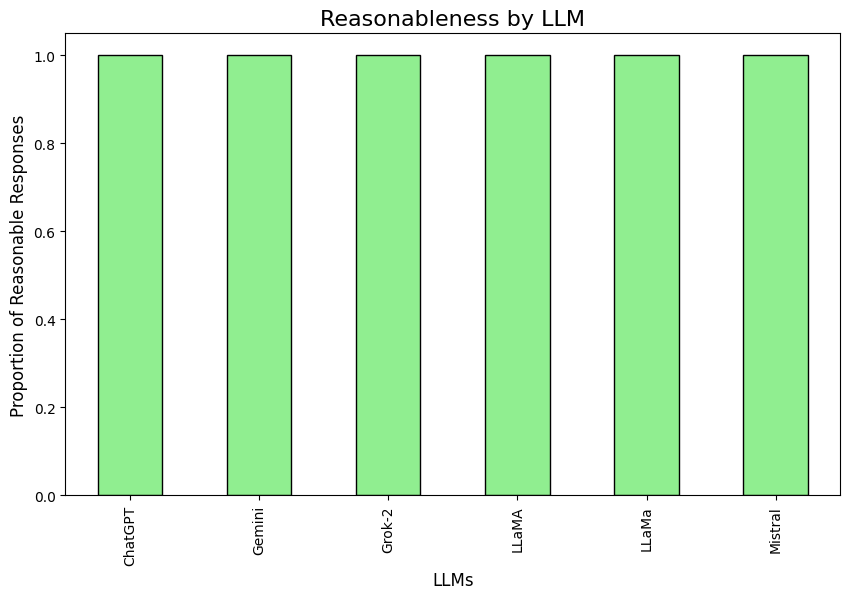

In [3]:
# Role Distribution
role_counts = df['Agent-role'].value_counts()
plt.figure(figsize=(10, 6))
role_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Role Distribution Among LLMs", fontsize=16)
plt.xlabel("Roles", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Reasonableness by LLM
reasonable_counts = df.groupby('character')['Reasonable'].mean()
plt.figure(figsize=(10, 6))
reasonable_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Reasonableness by LLM", fontsize=16)
plt.xlabel("LLMs", fontsize=12)
plt.ylabel("Proportion of Reasonable Responses", fontsize=12)
plt.show()


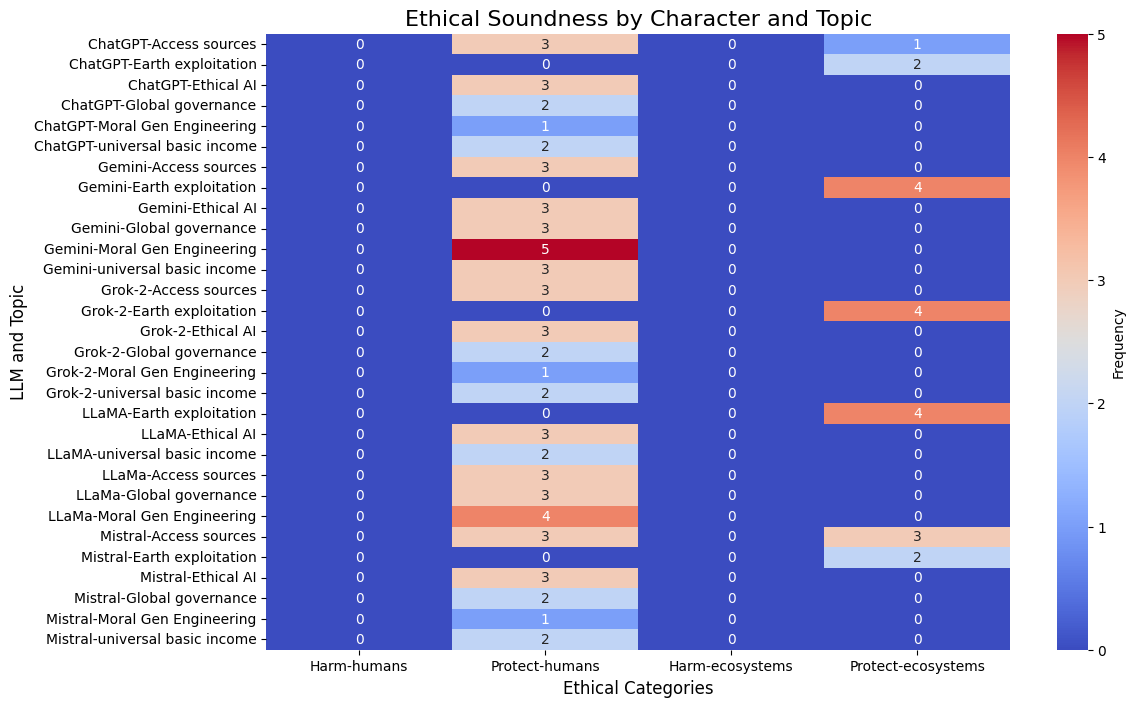

In [4]:
# Aggregate ethical soundness by LLM and topic
ethical_counts = df.groupby(['character', 'topic_discussion'])[['Harm-humans', 'Protect-humans', 'Harm-ecosystems', 'Protect-ecosystems']].sum()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(ethical_counts, annot=True, fmt="d", cmap="coolwarm", cbar_kws={'label': 'Frequency'})
plt.title("Ethical Soundness by Character and Topic", fontsize=16)
plt.xlabel("Ethical Categories", fontsize=12)
plt.ylabel("LLM and Topic", fontsize=12)
plt.show()


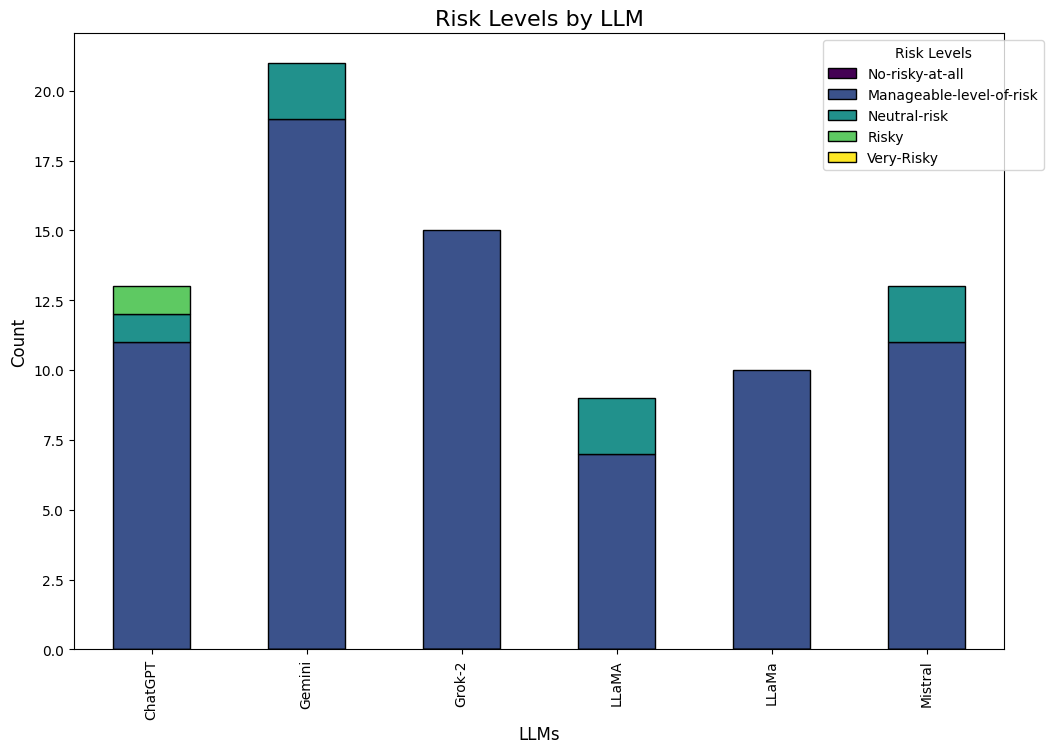

In [5]:
# Aggregate risk levels
risk_counts = df.groupby('character')[['No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky', 'Very-Risky']].sum()

# Stacked bar plot
risk_counts.plot(kind='bar', stacked=True, figsize=(12, 8), colormap="viridis", edgecolor='black')
plt.title("Risk Levels by LLM", fontsize=16)
plt.xlabel("LLMs", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Risk Levels", bbox_to_anchor=(1.05, 1))
plt.show()


<Figure size 1200x600 with 0 Axes>

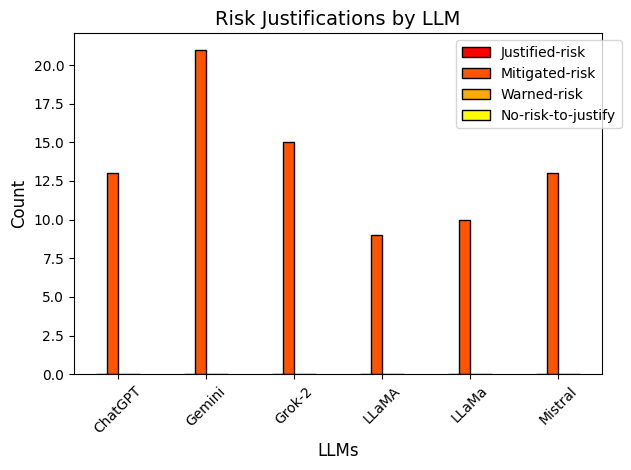

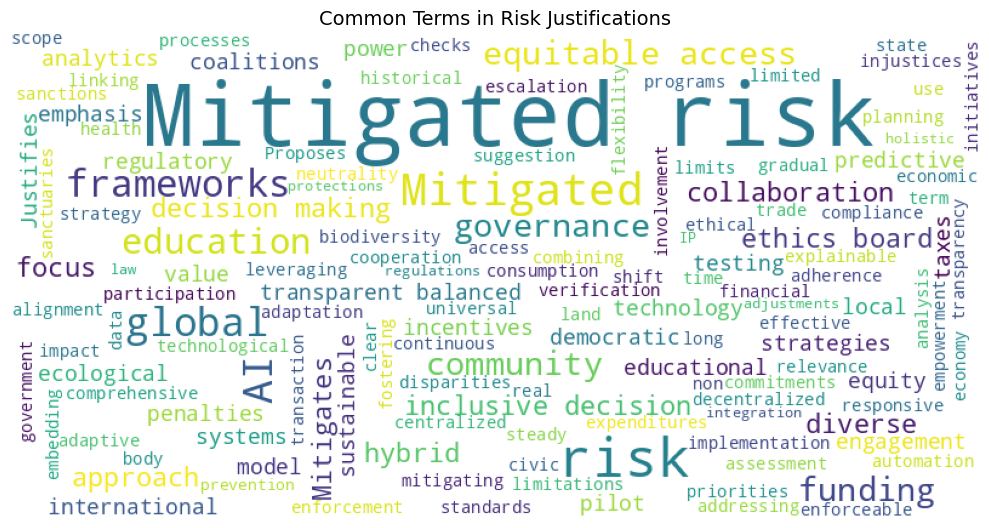

/var/folders/zt/2fc2dgl527j0fpwfk176q2k40000gn/T/ipykernel_29319/1004748122.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

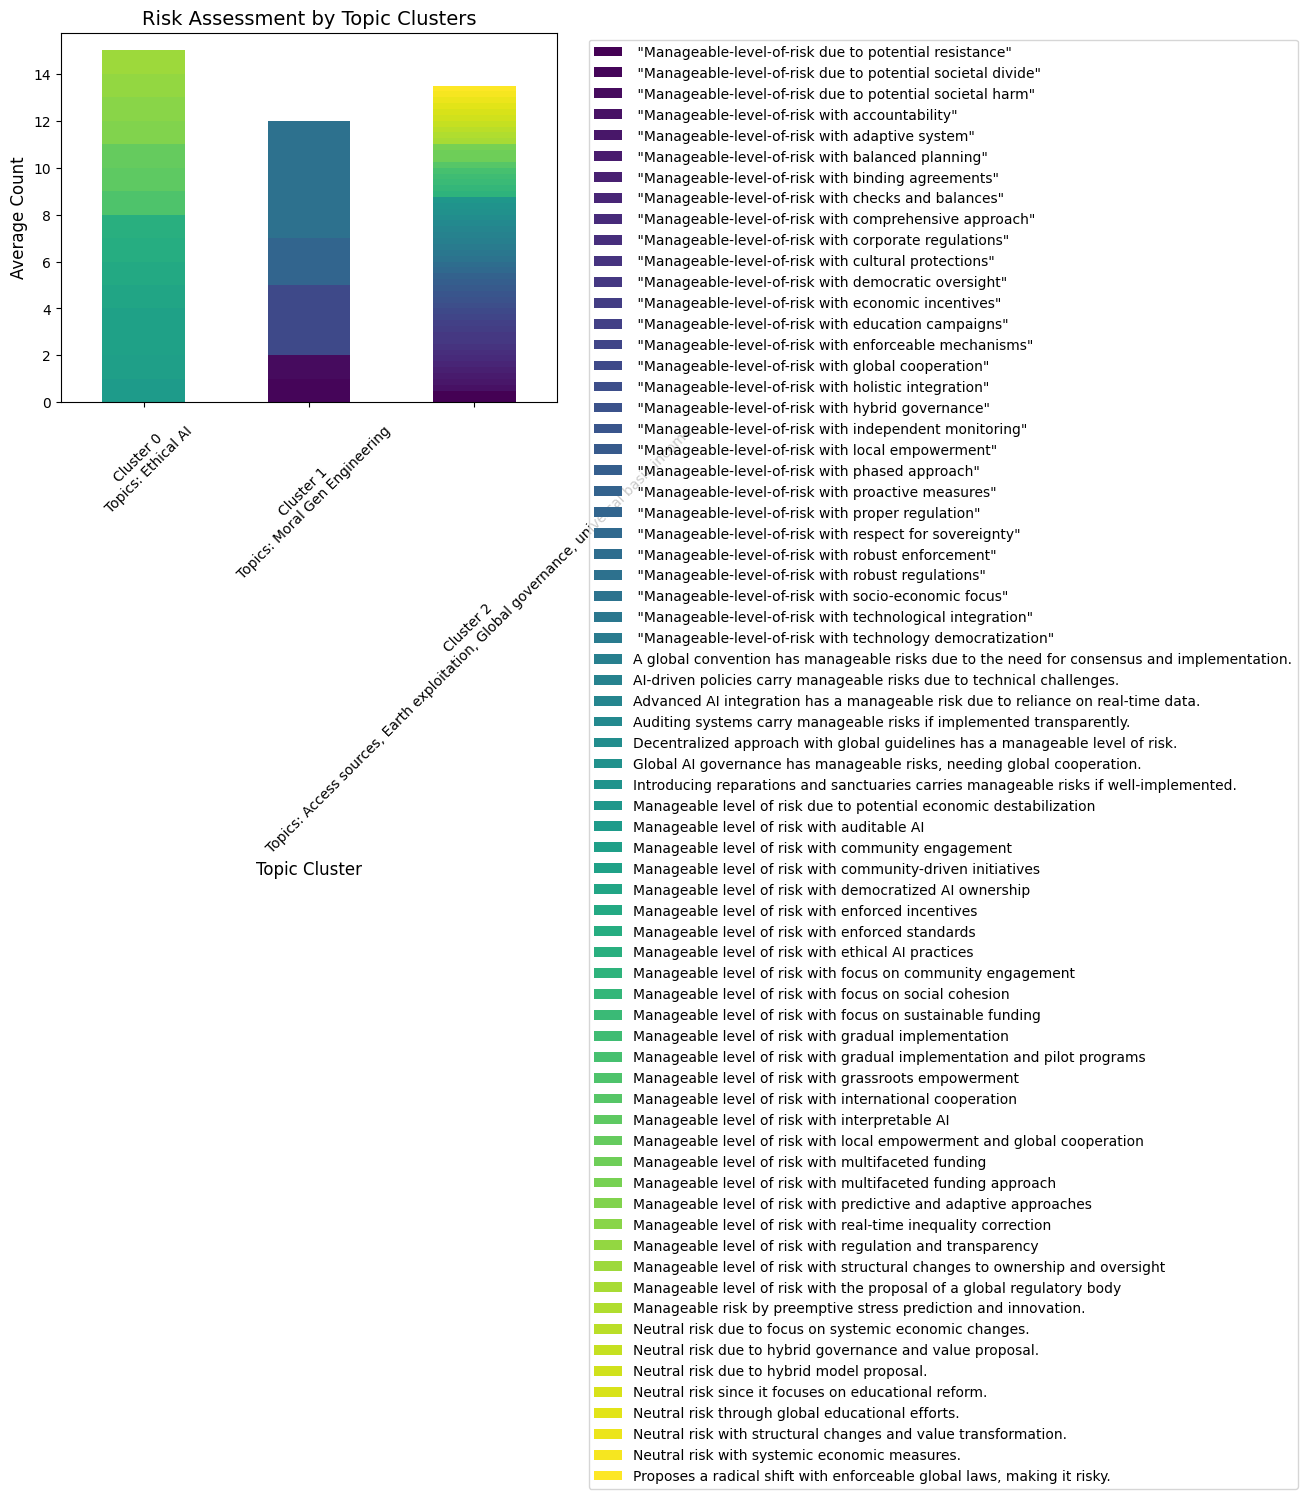

/var/folders/zt/2fc2dgl527j0fpwfk176q2k40000gn/T/ipykernel_29319/1004748122.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

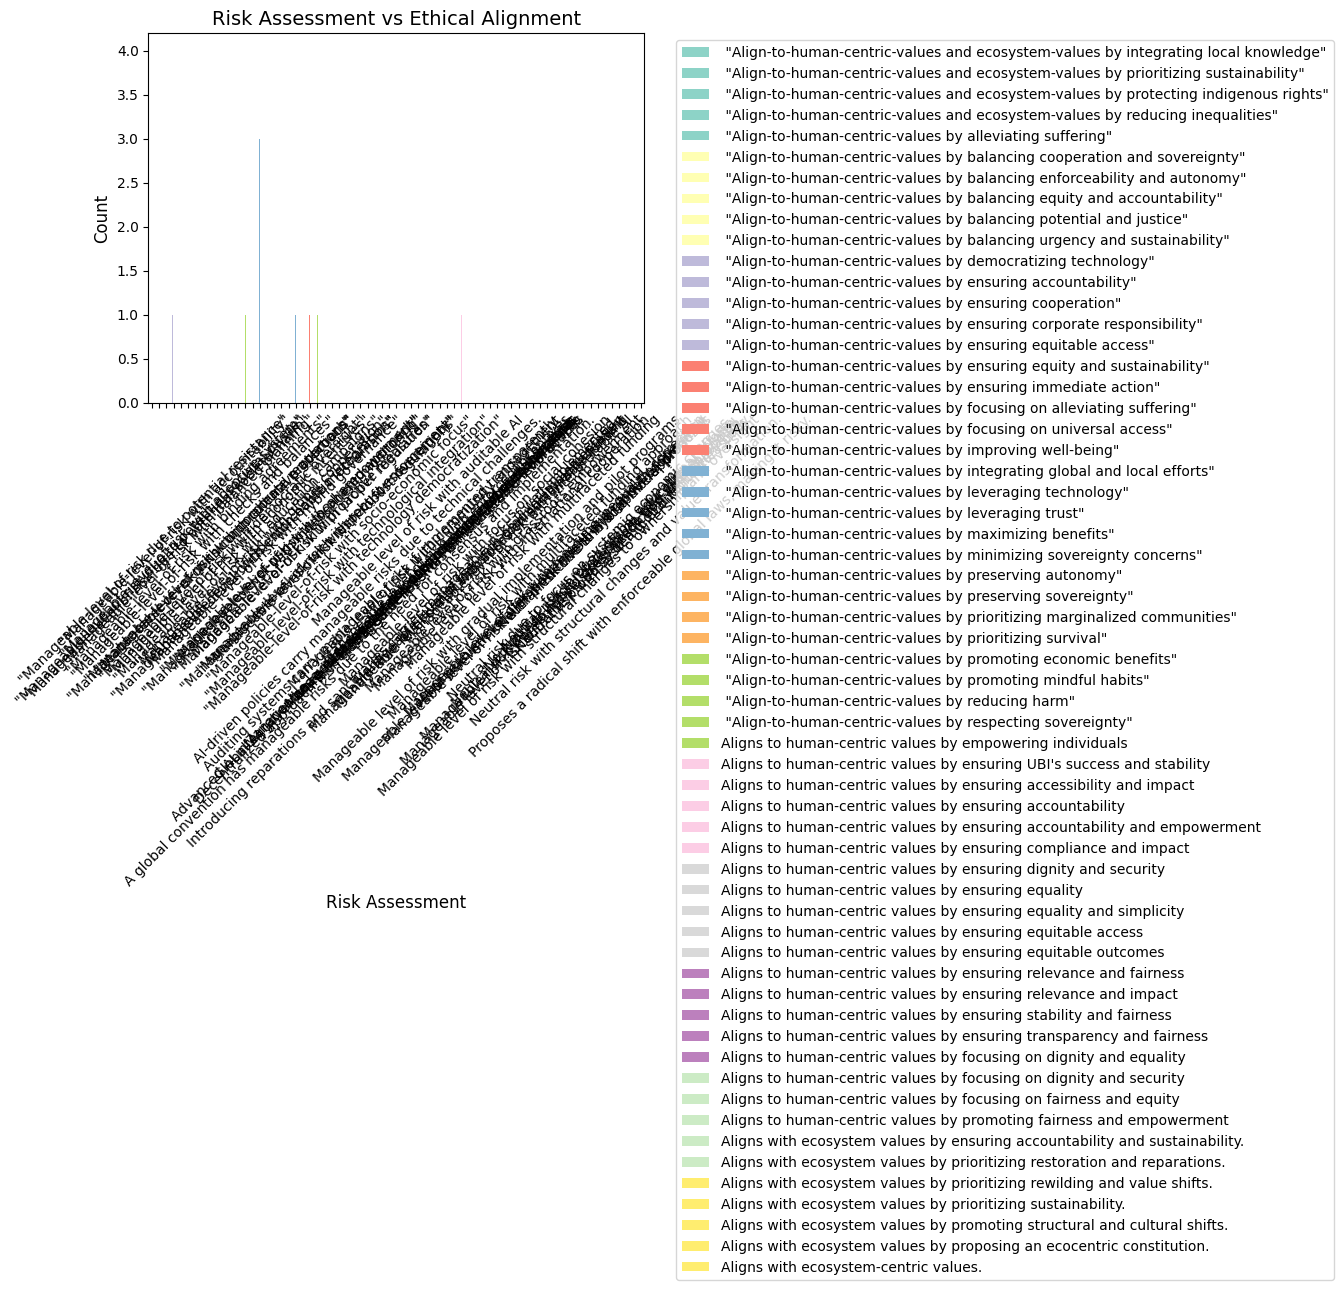

In [6]:

# 1. Original risk justification counts
plt.figure(figsize=(12, 6))
justification_counts = df.groupby('character')[['Justified-risk', 'Mitigated-risk', 'Warned-risk', 'No-risk-to-justify']].sum()
justification_counts.plot(kind='bar', colormap="autumn", edgecolor='black')
plt.title("Risk Justifications by LLM", fontsize=14)
plt.xlabel("LLMs", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# 2. Word cloud of risk justifications
plt.figure(figsize=(10, 6))
text = ' '.join(df['Risk Justification'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Common Terms in Risk Justifications', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Risk justification types by topic with clustering
# First create the cross tabulation
topic_just = pd.crosstab(df['topic_discussion'], df['Risk Assessment'])

# Perform k-means clustering on the risk assessment patterns
# Adjust the number of clusters to be less than or equal to the number of samples
n_clusters = min(3, len(topic_just))  # Ensure n_clusters is <= number of samples
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
topic_clusters = kmeans.fit_predict(topic_just)

# Create a new DataFrame with cluster assignments and add topic names
topic_just['Cluster'] = topic_clusters
topic_just['Topics'] = topic_just.index  # Add topic names as a column

# Calculate means by cluster and preserve topic information
cluster_means = topic_just.groupby('Cluster').agg({
    col: 'mean' if col not in ['Topics'] else lambda x: list(x)
    for col in topic_just.columns
})

# Rename clusters with topic information
cluster_means.index = [f'Cluster {i}\nTopics: {", ".join(topics)}' 
                      for i, topics in enumerate(cluster_means['Topics'])]

# Drop the helper columns before plotting
cluster_means = cluster_means.drop(['Topics', 'Cluster'], axis=1)

plt.figure(figsize=(12, 6))
cluster_means.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Risk Assessment by Topic Clusters', fontsize=14)
plt.xlabel('Topic Cluster', fontsize=12)
plt.ylabel('Average Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# 4. Relationship between risk justification and ethical alignment
plt.figure(figsize=(12, 6))
ethical_risk = pd.crosstab(df['Risk Assessment'], 
                          df['Alignment-and-Divergence'])
ethical_risk.plot(kind='bar', colormap='Set3')
plt.title('Risk Assessment vs Ethical Alignment', fontsize=14)
plt.xlabel('Risk Assessment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


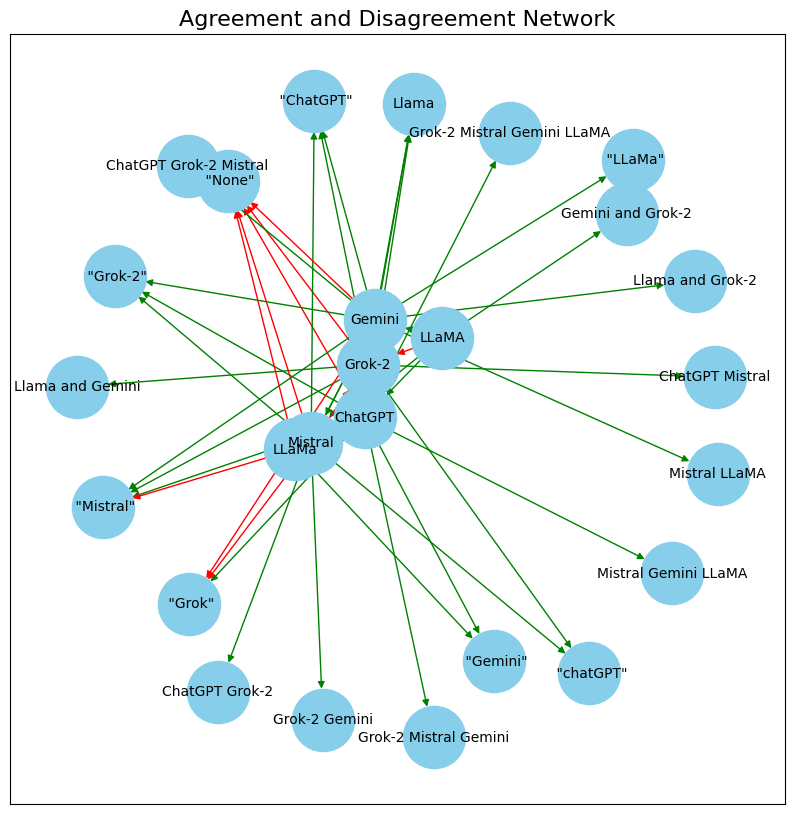

In [7]:
# Create directed graph
G = nx.DiGraph()
for _, row in df.iterrows():
    if pd.notna(row['Agreed-with']):
        G.add_edge(row['character'], row['Agreed-with'], color='green')
    if pd.notna(row['Disagreed-with']):
        G.add_edge(row['character'], row['Disagreed-with'], color='red')

# Draw graph
plt.figure(figsize=(10, 10))
colors = [G[u][v]['color'] for u, v in G.edges()]
nx.draw_networkx(G, with_labels=True, edge_color=colors, node_color="skyblue", font_size=10, node_size=2000)
plt.title("Agreement and Disagreement Network", fontsize=16)
plt.show()


In [8]:
# Calculate sentiment polarity for each comment
df['sentiment'] = df['comment'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Boxplot of sentiment by LLM
plt.figure(figsize=(12, 8))
sns.boxplot(x='character', y='sentiment', data=df, palette="pastel")
plt.title("Sentiment Distribution by Character", fontsize=16)
plt.xlabel("LLMs", fontsize=12)
plt.ylabel("Sentiment Polarity", fontsize=12)
plt.xticks(rotation=45)
plt.show()


ModuleNotFoundError: No module named 'textblob'

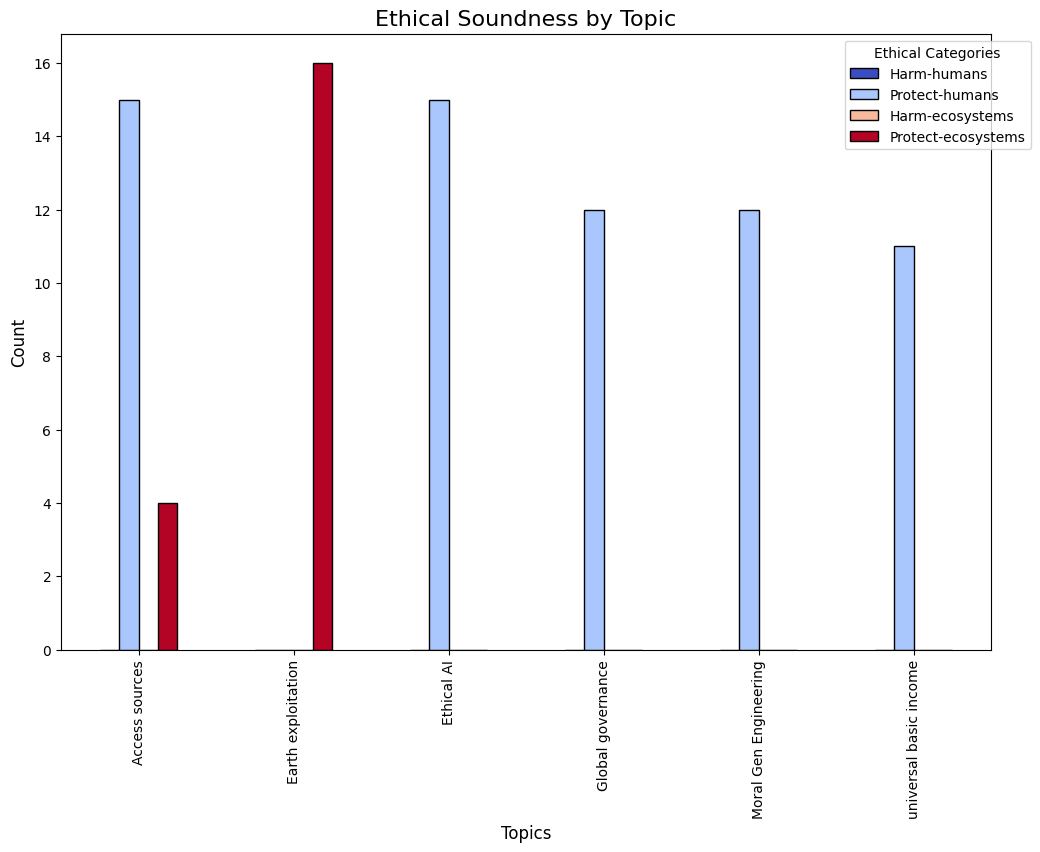

In [14]:
# Aggregate ethical soundness by topic
topic_ethics = df.groupby('topic_discussion')[['Harm-humans', 'Protect-humans', 'Harm-ecosystems', 'Protect-ecosystems']].sum()

# Bar plot
topic_ethics.plot(kind='bar', figsize=(12, 8), colormap="coolwarm", edgecolor='black')
plt.title("Ethical Soundness by Topic", fontsize=16)
plt.xlabel("Topics", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Ethical Categories", bbox_to_anchor=(1.05, 1))
plt.show()


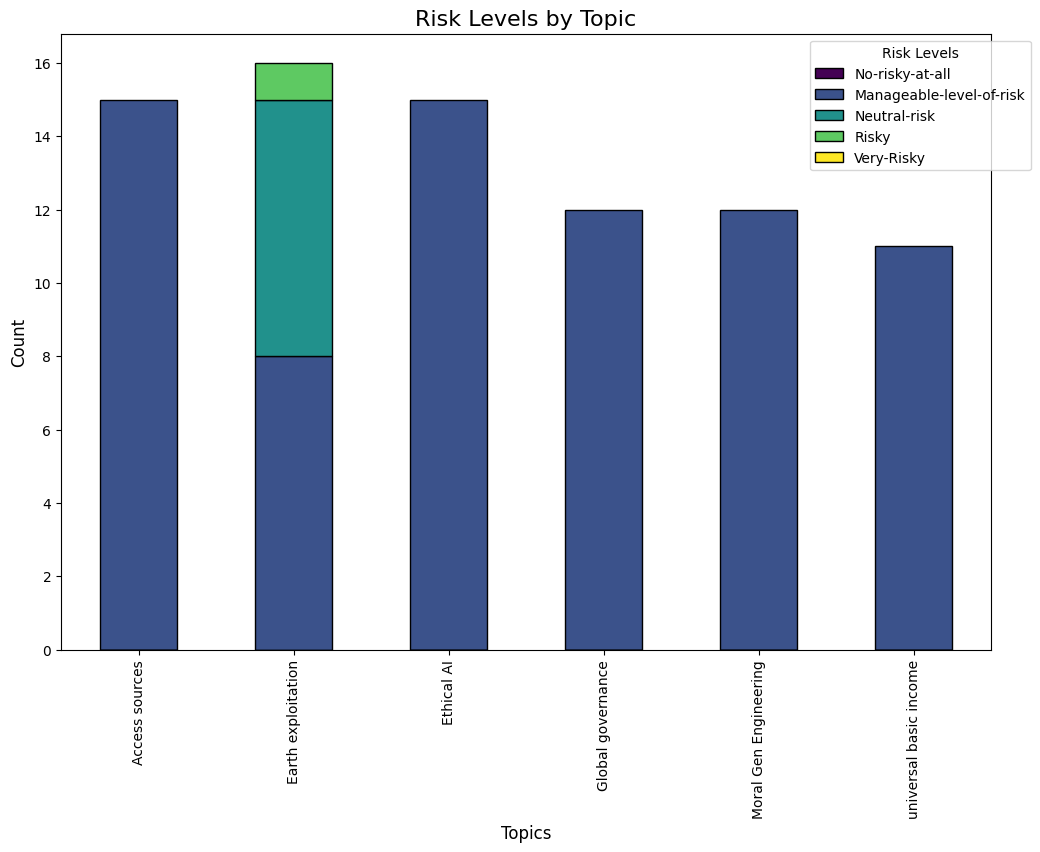

In [15]:
# Aggregate risk levels by topic
topic_risks = df.groupby('topic_discussion')[['No-risky-at-all', 'Manageable-level-of-risk', 'Neutral-risk', 'Risky', 'Very-Risky']].sum()

# Stacked bar plot
topic_risks.plot(kind='bar', stacked=True, figsize=(12, 8), colormap="viridis", edgecolor='black')
plt.title("Risk Levels by Topic", fontsize=16)
plt.xlabel("Topics", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Risk Levels", bbox_to_anchor=(1.05, 1))
plt.show()


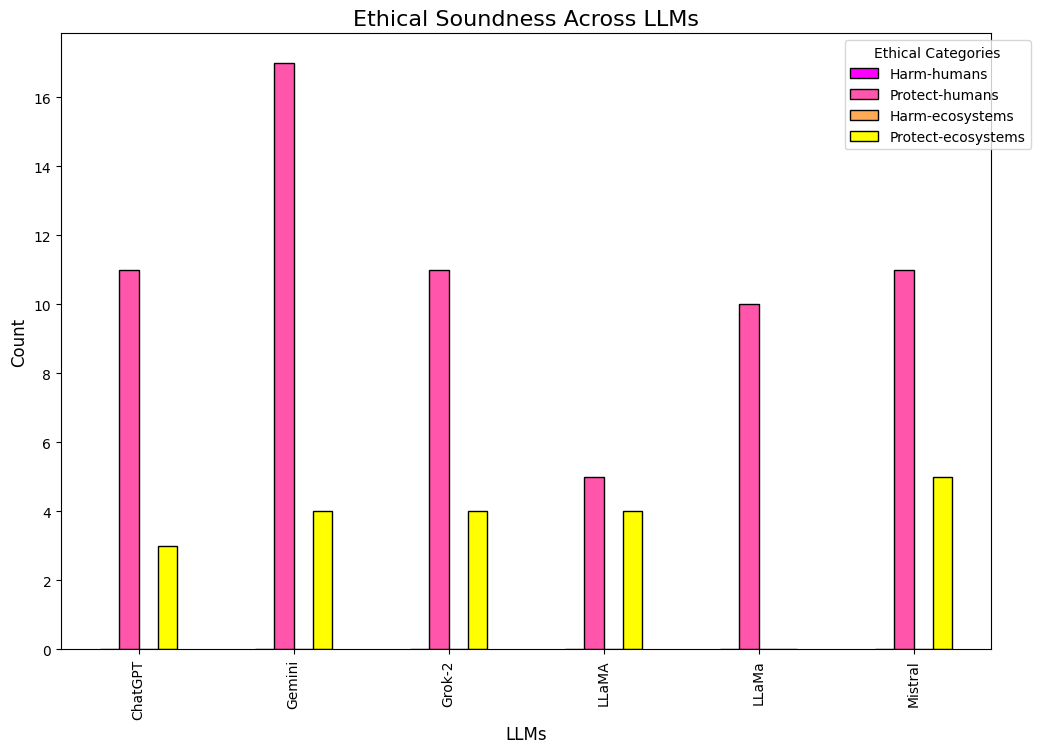

In [16]:
# Aggregate ethical soundness by LLM
llm_ethics = df.groupby('character')[['Harm-humans', 'Protect-humans', 'Harm-ecosystems', 'Protect-ecosystems']].sum()

# Bar plot
llm_ethics.plot(kind='bar', figsize=(12, 8), colormap="spring", edgecolor='black')
plt.title("Ethical Soundness Across LLMs", fontsize=16)
plt.xlabel("LLMs", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Ethical Categories", bbox_to_anchor=(1.05, 1))
plt.show()
